# 쇼핑몰 데이터베이스 (MySQL + Jupyter)

## 학습 목표
- Python에서 MySQL 연결 및 관리
- CRUD 작업 수행
- JOIN을 활용한 데이터 결합 및 분석

## 환경변수 사용
중요 정보(비밀번호 등)는 `.env` 파일에 저장하여 보안 유지

##  라이브러리 설치 및 Import

In [30]:
# 필요한 라이브러리 설치 (처음 한 번만 실행)
%pip install mysql-connector-python python-dotenv pandas

Note: you may need to restart the kernel to use updated packages.


In [31]:
# 라이브러리 Import
import mysql.connector
from mysql.connector import Error
from datetime import datetime
import os
from dotenv import load_dotenv
import pandas as pd

# 환경변수 로드
load_dotenv()

print(" 라이브러리 로드 완료!")

 라이브러리 로드 완료!


##  데이터베이스 연결 설정

###  환경변수 설정 방법

1. 프로젝트 폴더에 `.env` 파일 생성
2. 아래 내용을 입력하고 저장:

```
DB_HOST=localhost
DB_USER=root
DB_PASSWORD=your_mysql_password
DB_NAME=shop_db
DB_PORT=3306
```

3. `.gitignore`에 `.env` 추가 (Git 사용 시)

In [32]:
# 환경변수에서 MySQL 연결 정보 로드
DB_CONFIG = {
    'host': os.getenv('DB_HOST', 'localhost'),
    'user': os.getenv('DB_USER', 'root'),
    'password': os.getenv('DB_PASSWORD', ''),
    'database': os.getenv('DB_NAME', 'shop_db'),
    'port': int(os.getenv('DB_PORT', 3306))
}

print(" 데이터베이스 연결 설정:")
print(f"   Host: {DB_CONFIG['host']}")
print(f"   User: {DB_CONFIG['user']}")
print(f"   Database: {DB_CONFIG['database']}")
print(f"   Port: {DB_CONFIG['port']}")
print(f"   Password: {'*' * len(DB_CONFIG['password']) if DB_CONFIG['password'] else '(비어있음)'}")

 데이터베이스 연결 설정:
   Host: localhost
   User: root
   Database: shop_db
   Port: 3306
   Password: *********


##  데이터베이스 연결 클래스

In [33]:
class ShopDB:
    """쇼핑몰 데이터베이스 관리 클래스 (MySQL)"""
    
    def __init__(self, host, user, password, database, port=3306):
        self.host = host
        self.user = user
        self.password = password
        self.database = database
        self.port = port
        self.conn = None
        self.cursor = None
    
    def connect(self):
        """데이터베이스 연결"""
        try:
            self.conn = mysql.connector.connect(
                host=self.host,
                user=self.user,
                password=self.password,
                port=self.port
            )
            self.cursor = self.conn.cursor()
            
            # 데이터베이스 생성 및 선택
            self.cursor.execute(
                f"CREATE DATABASE IF NOT EXISTS {self.database} "
                "CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci"
            )
            self.cursor.execute(f"USE {self.database}")
            
            print(f" MySQL 데이터베이스 '{self.database}' 연결 성공!")
            return True
        except Error as e:
            print(f" 연결 실패: {e}")
            return False
    
    def close(self):
        """연결 종료"""
        if self.cursor:
            self.cursor.close()
        if self.conn and self.conn.is_connected():
            self.conn.close()
            print(" 연결 종료")
    
    def execute(self, query, params=None):
        """쿼리 실행"""
        try:
            if params:
                self.cursor.execute(query, params)
            else:
                self.cursor.execute(query)
            return True
        except Error as e:
            print(f"❌ 쿼리 오류: {e}")
            return False
    
    def fetchall(self):
        return self.cursor.fetchall()
    
    def fetchone(self):
        return self.cursor.fetchone()
    
    def commit(self):
        if self.conn:
            self.conn.commit()
    
    def query_to_dataframe(self, query, params=None):
        """쿼리 결과를 Pandas DataFrame으로 반환"""
        self.execute(query, params)
        columns = [desc[0] for desc in self.cursor.description]
        data = self.fetchall()
        return pd.DataFrame(data, columns=columns)

print(" ShopDB 클래스 정의 완료!")

 ShopDB 클래스 정의 완료!


##  데이터베이스 연결

In [34]:
# 데이터베이스 연결
db = ShopDB(**DB_CONFIG)

if db.connect():
    print("\n🎉 데이터베이스 연결 준비 완료!")
else:
    print("\n⚠️ 연결 실패. 환경변수 설정을 확인하세요.")

 MySQL 데이터베이스 'shop_db' 연결 성공!

🎉 데이터베이스 연결 준비 완료!


##  테이블 생성 (CREATE)

In [35]:
# 기존 테이블 삭제 (초기화)
tables = ['order_details', 'orders', 'customers', 'products']
for table in tables:
    db.execute(f"DROP TABLE IF EXISTS {table}")

print(" 기존 테이블 삭제 완료\n")

# 1. customers 테이블
db.execute("""
    CREATE TABLE customers (
        customer_id INT AUTO_INCREMENT PRIMARY KEY,
        name VARCHAR(100) NOT NULL,
        email VARCHAR(100) UNIQUE NOT NULL,
        grade VARCHAR(20) DEFAULT 'Bronze',
        point INT DEFAULT 0,
        join_date DATE NOT NULL
    )
""")
print(" customers 테이블 생성")

# 2. products 테이블
db.execute("""
    CREATE TABLE products (
        product_id INT AUTO_INCREMENT PRIMARY KEY,
        product_name VARCHAR(200) NOT NULL,
        category VARCHAR(50) NOT NULL,
        price INT NOT NULL,
        stock INT DEFAULT 0
    )
""")
print(" products 테이블 생성")

# 3. orders 테이블
db.execute("""
    CREATE TABLE orders (
        order_id INT AUTO_INCREMENT PRIMARY KEY,
        customer_id INT NOT NULL,
        order_date DATETIME NOT NULL,
        total_amount INT NOT NULL,
        status VARCHAR(20) DEFAULT 'Pending',
        FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
    )
""")
print(" orders 테이블 생성")

# 4. order_details 테이블
db.execute("""
    CREATE TABLE order_details (
        detail_id INT AUTO_INCREMENT PRIMARY KEY,
        order_id INT NOT NULL,
        product_id INT NOT NULL,
        quantity INT NOT NULL,
        unit_price INT NOT NULL,
        subtotal INT NOT NULL,
        FOREIGN KEY (order_id) REFERENCES orders(order_id),
        FOREIGN KEY (product_id) REFERENCES products(product_id)
    )
""")
print(" order_details 테이블 생성")

db.commit()
print("\n 모든 테이블 생성 완료!")

 기존 테이블 삭제 완료

 customers 테이블 생성
 products 테이블 생성
 orders 테이블 생성
 order_details 테이블 생성

 모든 테이블 생성 완료!


##  샘플 데이터 삽입 (INSERT)

In [36]:
# 고객 데이터
customers_data = [
    ('김철수', 'kim@email.com', 'Gold', 5000, '2023-01-15'),
    ('이영희', 'lee@email.com', 'Silver', 3000, '2023-03-20'),
    ('박민수', 'park@email.com', 'Bronze', 1000, '2023-06-10'),
    ('최지은', 'choi@email.com', 'Gold', 6000, '2023-02-05'),
    ('정수진', 'jung@email.com', 'Silver', 2500, '2023-04-18'),
    ('강동원', 'kang@email.com', 'Bronze', 500, '2024-01-20'),
    ('윤서연', 'yoon@email.com', 'Silver', 3500, '2023-05-12'),
    ('임하늘', 'lim@email.com', 'Bronze', 800, '2024-02-01'),
    ('송민호', 'song@email.com', 'Gold', 7000, '2023-01-28'),
    ('한지민', 'han@email.com', 'Bronze', 1200, '2023-07-15'),
]

for customer in customers_data:
    db.execute(
        "INSERT INTO customers (name, email, grade, point, join_date) VALUES (%s, %s, %s, %s, %s)",
        customer
    )

print(f" 고객 {len(customers_data)}명 삽입 완료")
db.commit()

 고객 10명 삽입 완료


In [37]:
# 상품 데이터
products_data = [
    ('노트북', '전자기기', 1200000, 15),
    ('무선마우스', '전자기기', 35000, 50),
    ('키보드', '전자기기', 89000, 30),
    ('모니터', '전자기기', 350000, 20),
    ('청바지', '의류', 59000, 100),
    ('티셔츠', '의류', 25000, 150),
    ('운동화', '의류', 89000, 80),
    ('백팩', '가방', 45000, 40),
    ('텀블러', '생활용품', 15000, 200),
    ('책상스탠드', '생활용품', 28000, 60),
]

for product in products_data:
    db.execute(
        "INSERT INTO products (product_name, category, price, stock) VALUES (%s, %s, %s, %s)",
        product
    )

print(f" 상품 {len(products_data)}개 삽입 완료")
db.commit()

 상품 10개 삽입 완료


In [38]:
# 주문 데이터
orders_data = [
    (1, '2024-02-15 10:30:00', 1235000, 'Completed'),
    (1, '2024-02-20 14:20:00', 89000, 'Completed'),
    (2, '2024-02-16 09:15:00', 375000, 'Completed'),
    (3, '2024-02-17 16:45:00', 143000, 'Completed'),
    (4, '2024-02-18 11:00:00', 1550000, 'Completed'),
    (5, '2024-02-19 13:30:00', 84000, 'Completed'),
    (6, '2024-02-21 10:00:00', 59000, 'Pending'),
    (7, '2024-02-22 15:20:00', 254000, 'Completed'),
    (8, '2024-02-23 12:10:00', 45000, 'Cancelled'),
    (9, '2024-02-24 14:50:00', 1289000, 'Completed'),
]

for order in orders_data:
    db.execute(
        "INSERT INTO orders (customer_id, order_date, total_amount, status) VALUES (%s, %s, %s, %s)",
        order
    )

print(f" 주문 {len(orders_data)}건 삽입 완료")
db.commit()

 주문 10건 삽입 완료


In [39]:
# 주문 상세 데이터
order_details_data = [
    (1, 1, 1, 1200000, 1200000),
    (1, 2, 1, 35000, 35000),
    (2, 3, 1, 89000, 89000),
    (3, 4, 1, 350000, 350000),
    (3, 5, 1, 25000, 25000),
    (4, 5, 2, 59000, 118000),
    (4, 6, 1, 25000, 25000),
    (5, 1, 1, 1200000, 1200000),
    (5, 4, 1, 350000, 350000),
    (6, 7, 1, 89000, 89000),
    (7, 5, 1, 59000, 59000),
    (8, 2, 3, 35000, 105000),
    (8, 3, 1, 89000, 89000),
    (8, 9, 2, 15000, 30000),
    (8, 10, 1, 28000, 28000),
    (9, 8, 1, 45000, 45000),
    (10, 1, 1, 1200000, 1200000),
    (10, 3, 1, 89000, 89000),
]

for detail in order_details_data:
    db.execute(
        "INSERT INTO order_details (order_id, product_id, quantity, unit_price, subtotal) VALUES (%s, %s, %s, %s, %s)",
        detail
    )

print(f" 주문 상세 {len(order_details_data)}건 삽입 완료")
db.commit()

print("\n 모든 샘플 데이터 삽입 완료!")

 주문 상세 18건 삽입 완료

 모든 샘플 데이터 삽입 완료!


##  데이터 조회 (SELECT)

In [40]:
# 고객 조회
df_customers = db.query_to_dataframe("SELECT * FROM customers")
print(" 고객 데이터:")
df_customers

 고객 데이터:


,customer_id,name,email,grade,point,join_date
0,1,김철수,kim@email.com,Gold,5000,2023-01-15
1,2,이영희,lee@email.com,Silver,3000,2023-03-20
2,3,박민수,park@email.com,Bronze,1000,2023-06-10
3,4,최지은,choi@email.com,Gold,6000,2023-02-05
4,5,정수진,jung@email.com,Silver,2500,2023-04-18
5,6,강동원,kang@email.com,Bronze,500,2024-01-20
6,7,윤서연,yoon@email.com,Silver,3500,2023-05-12
7,8,임하늘,lim@email.com,Bronze,800,2024-02-01
8,9,송민호,song@email.com,Gold,7000,2023-01-28
9,10,한지민,han@email.com,Bronze,1200,2023-07-15


In [41]:
# 상품 조회
df_products = db.query_to_dataframe("SELECT * FROM products")
print(" 상품 데이터:")
df_products

 상품 데이터:


,product_id,product_name,category,price,stock
0,1,노트북,전자기기,1200000,15
1,2,무선마우스,전자기기,35000,50
2,3,키보드,전자기기,89000,30
3,4,모니터,전자기기,350000,20
4,5,청바지,의류,59000,100
5,6,티셔츠,의류,25000,150
6,7,운동화,의류,89000,80
7,8,백팩,가방,45000,40
8,9,텀블러,생활용품,15000,200
9,10,책상스탠드,생활용품,28000,60


##  JOIN 실습

###  예제 1: INNER JOIN - 고객 + 주문

In [42]:
query = """
    SELECT 
        c.name AS '고객명',
        c.grade AS '등급',
        o.order_id AS '주문번호',
        o.order_date AS '주문일시',
        o.total_amount AS '주문금액',
        o.status AS '상태'
    FROM customers c
    INNER JOIN orders o ON c.customer_id = o.customer_id
    ORDER BY o.order_date DESC
    LIMIT 10
"""

df_result = db.query_to_dataframe(query)
print(" INNER JOIN: 고객별 주문 내역")
df_result

 INNER JOIN: 고객별 주문 내역


,고객명,등급,주문번호,주문일시,주문금액,상태
0,송민호,Gold,10,2024-02-24 14:50:00,1289000,Completed
1,임하늘,Bronze,9,2024-02-23 12:10:00,45000,Cancelled
2,윤서연,Silver,8,2024-02-22 15:20:00,254000,Completed
3,강동원,Bronze,7,2024-02-21 10:00:00,59000,Pending
4,김철수,Gold,2,2024-02-20 14:20:00,89000,Completed
5,정수진,Silver,6,2024-02-19 13:30:00,84000,Completed
6,최지은,Gold,5,2024-02-18 11:00:00,1550000,Completed
7,박민수,Bronze,4,2024-02-17 16:45:00,143000,Completed
8,이영희,Silver,3,2024-02-16 09:15:00,375000,Completed
9,김철수,Gold,1,2024-02-15 10:30:00,1235000,Completed


###  예제 2: LEFT JOIN - 전체 고객 (주문 여부 무관)

In [43]:
query = """
    SELECT 
        c.customer_id AS '고객번호',
        c.name AS '고객명',
        c.grade AS '등급',
        COUNT(o.order_id) AS '주문횟수',
        COALESCE(SUM(o.total_amount), 0) AS '총구매금액'
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    GROUP BY c.customer_id, c.name, c.grade
    ORDER BY 총구매금액 DESC
"""

df_result = db.query_to_dataframe(query)
print(" LEFT JOIN: 모든 고객과 주문 정보")
df_result

 LEFT JOIN: 모든 고객과 주문 정보


,고객번호,고객명,등급,주문횟수,총구매금액
0,4,최지은,Gold,1,1550000
1,1,김철수,Gold,2,1324000
2,9,송민호,Gold,1,1289000
3,2,이영희,Silver,1,375000
4,7,윤서연,Silver,1,254000
5,3,박민수,Bronze,1,143000
6,5,정수진,Silver,1,84000
7,6,강동원,Bronze,1,59000
8,8,임하늘,Bronze,1,45000
9,10,한지민,Bronze,0,0


###  예제 3: 4개 테이블 JOIN - 완전한 주문 정보

In [44]:
query = """
    SELECT 
        c.name AS '고객명',
        c.grade AS '등급',
        o.order_id AS '주문번호',
        DATE(o.order_date) AS '주문일',
        p.product_name AS '상품명',
        p.category AS '카테고리',
        od.quantity AS '수량',
        od.unit_price AS '단가',
        od.subtotal AS '소계'
    FROM customers c
    INNER JOIN orders o ON c.customer_id = o.customer_id
    INNER JOIN order_details od ON o.order_id = od.order_id
    INNER JOIN products p ON od.product_id = p.product_id
    ORDER BY o.order_date DESC
    LIMIT 15
"""

df_result = db.query_to_dataframe(query)
print(" 4개 테이블 JOIN: 완전한 주문 정보")
df_result

 4개 테이블 JOIN: 완전한 주문 정보


,고객명,등급,주문번호,주문일,상품명,카테고리,수량,단가,소계
0,송민호,Gold,10,2024-02-24,노트북,전자기기,1,1200000,1200000
1,송민호,Gold,10,2024-02-24,키보드,전자기기,1,89000,89000
2,임하늘,Bronze,9,2024-02-23,백팩,가방,1,45000,45000
3,윤서연,Silver,8,2024-02-22,무선마우스,전자기기,3,35000,105000
4,윤서연,Silver,8,2024-02-22,키보드,전자기기,1,89000,89000
5,윤서연,Silver,8,2024-02-22,텀블러,생활용품,2,15000,30000
6,윤서연,Silver,8,2024-02-22,책상스탠드,생활용품,1,28000,28000
7,강동원,Bronze,7,2024-02-21,청바지,의류,1,59000,59000
8,김철수,Gold,2,2024-02-20,키보드,전자기기,1,89000,89000
9,정수진,Silver,6,2024-02-19,운동화,의류,1,89000,89000


###  예제 4: JOIN + 집계 함수 - 고객별 구매 통계

In [45]:
query = """
    SELECT 
        c.name AS '고객명',
        c.grade AS '등급',
        COUNT(DISTINCT o.order_id) AS '주문횟수',
        COUNT(od.detail_id) AS '구매상품수',
        SUM(od.subtotal) AS '총구매금액',
        ROUND(AVG(o.total_amount), 0) AS '평균주문금액'
    FROM customers c
    INNER JOIN orders o ON c.customer_id = o.customer_id
    INNER JOIN order_details od ON o.order_id = od.order_id
    WHERE o.status = 'Completed'
    GROUP BY c.customer_id, c.name, c.grade
    ORDER BY 총구매금액 DESC
"""

df_result = db.query_to_dataframe(query)
print("📊 고객별 구매 통계")
df_result

📊 고객별 구매 통계


,고객명,등급,주문횟수,구매상품수,총구매금액,평균주문금액
0,최지은,Gold,1,2,1550000,1550000
1,김철수,Gold,2,3,1324000,853000
2,송민호,Gold,1,2,1289000,1289000
3,이영희,Silver,1,2,375000,375000
4,윤서연,Silver,1,4,252000,254000
5,박민수,Bronze,1,2,143000,143000
6,정수진,Silver,1,1,89000,84000


###  예제 5: 카테고리별 매출 분석

In [46]:
query = """
    SELECT 
        p.category AS '카테고리',
        COUNT(DISTINCT p.product_id) AS '상품수',
        SUM(od.quantity) AS '총판매수량',
        SUM(od.subtotal) AS '총매출액',
        ROUND(AVG(od.subtotal), 0) AS '평균판매금액'
    FROM products p
    INNER JOIN order_details od ON p.product_id = od.product_id
    GROUP BY p.category
    ORDER BY 총매출액 DESC
"""

df_result = db.query_to_dataframe(query)
print("📊 카테고리별 매출 분석")
df_result

📊 카테고리별 매출 분석


,카테고리,상품수,총판매수량,총매출액,평균판매금액
0,전자기기,4,12,4707000,470700
1,의류,3,6,316000,63200
2,생활용품,2,3,58000,29000
3,가방,1,1,45000,45000


###  예제 6: 베스트셀러 TOP 5

In [47]:
query = """
    SELECT 
        p.product_name AS '상품명',
        p.category AS '카테고리',
        p.price AS '정가',
        SUM(od.quantity) AS '총판매수량',
        SUM(od.subtotal) AS '총매출액'
    FROM products p
    INNER JOIN order_details od ON p.product_id = od.product_id
    GROUP BY p.product_id, p.product_name, p.category, p.price
    ORDER BY 총매출액 DESC
    LIMIT 5
"""

df_result = db.query_to_dataframe(query)
print(" 베스트셀러 TOP 5")
df_result

 베스트셀러 TOP 5


,상품명,카테고리,정가,총판매수량,총매출액
0,노트북,전자기기,1200000,3,3600000
1,모니터,전자기기,350000,2,700000
2,키보드,전자기기,89000,3,267000
3,청바지,의류,59000,4,202000
4,무선마우스,전자기기,35000,4,140000


##  CRUD 작업

###  UPDATE - 데이터 수정

In [48]:
# 고객 등급 수정
db.execute(
    "UPDATE customers SET grade = %s WHERE customer_id = %s",
    ('Gold', 3)
)
db.commit()
print(" 고객 ID 3의 등급을 Gold로 변경")

# 확인
df = db.query_to_dataframe("SELECT * FROM customers WHERE customer_id = 3")
df

 고객 ID 3의 등급을 Gold로 변경


,customer_id,name,email,grade,point,join_date
0,3,박민수,park@email.com,Gold,1000,2023-06-10


### DELETE - 데이터 삭제

In [49]:
# 주문 삭제 (주문 상세도 함께)
db.execute("DELETE FROM order_details WHERE order_id = %s", (9,))
db.execute("DELETE FROM orders WHERE order_id = %s", (9,))
db.commit()
print(" 주문 ID 9 삭제 완료")

# 확인
df = db.query_to_dataframe("SELECT * FROM orders WHERE order_id = 9")
print(f"\n결과: {len(df)}건 (0이면 삭제 성공)")
df

 주문 ID 9 삭제 완료

결과: 0건 (0이면 삭제 성공)


,order_id,customer_id,order_date,total_amount,status


##  사용자 정의 쿼리

자유롭게 SQL 쿼리를 작성하고 실행해보세요!

In [50]:
# 여기에 원하는 쿼리를 작성하세요
query = """
    SELECT 
        c.name,
        c.grade,
        COUNT(o.order_id) AS order_count
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    GROUP BY c.customer_id, c.name, c.grade
    ORDER BY order_count DESC
"""

df_result = db.query_to_dataframe(query)
df_result

,name,grade,order_count
0,김철수,Gold,2
1,이영희,Silver,1
2,박민수,Gold,1
3,최지은,Gold,1
4,정수진,Silver,1
5,강동원,Bronze,1
6,윤서연,Silver,1
7,송민호,Gold,1
8,임하늘,Bronze,0
9,한지민,Bronze,0


##  데이터 시각화 (Bonus)

In [51]:
%conda install matplotlib

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


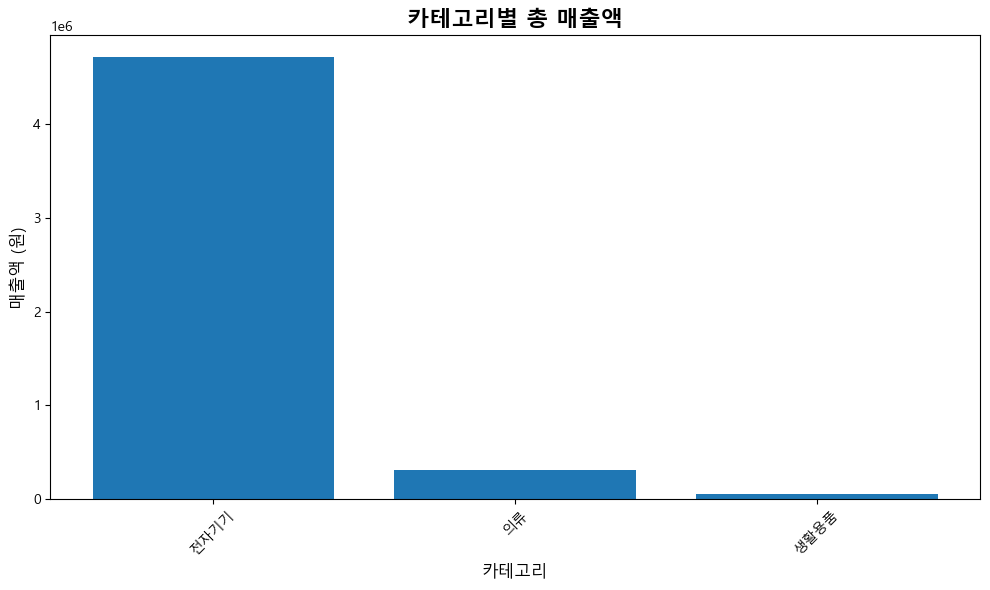

In [52]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# matplotlib.rcParams['font.family'] = 'AppleGothic'  # macOS
matplotlib.rcParams['axes.unicode_minus'] = False

# 카테고리별 매출 차트
query = """
    SELECT 
        p.category,
        SUM(od.subtotal) AS total_sales
    FROM products p
    INNER JOIN order_details od ON p.product_id = od.product_id
    GROUP BY p.category
    ORDER BY total_sales DESC
"""

df_chart = db.query_to_dataframe(query)

plt.figure(figsize=(10, 6))
plt.bar(df_chart['category'], df_chart['total_sales'])
plt.title('카테고리별 총 매출액', fontsize=16, fontweight='bold')
plt.xlabel('카테고리', fontsize=12)
plt.ylabel('매출액 (원)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  연결 종료

In [53]:
# 데이터베이스 연결 종료
db.close()
print("\n 실습 완료! 수고하셨습니다!")

 연결 종료

 실습 완료! 수고하셨습니다!


In [56]:
"abc 123".startswith('abc')

True